# Task 5 – Uncertainty Evaluation
The model is run multiple times with dropout to measure uncertainty.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
# Paths to data
train_images_folder = "Data/Training/Training_Images"
train_csv = "Data/Training/Training_LabelsDemographic.csv"

# Load labels
train_df = pd.read_csv(train_csv)

train_df.head()

,image,myopic_maculopathy_grade,age,sex,height,weight,data_center
0,mmac_task_1_train_0001.png,0,51,male,183.5,78.9,1
1,mmac_task_1_train_0002.png,0,51,male,183.5,78.9,1
2,mmac_task_1_train_0003.png,0,50,male,184.5,81.7,1
3,mmac_task_1_train_0004.png,0,50,male,184.5,81.7,1
4,mmac_task_1_train_0005.png,0,49,male,184.5,82.2,1


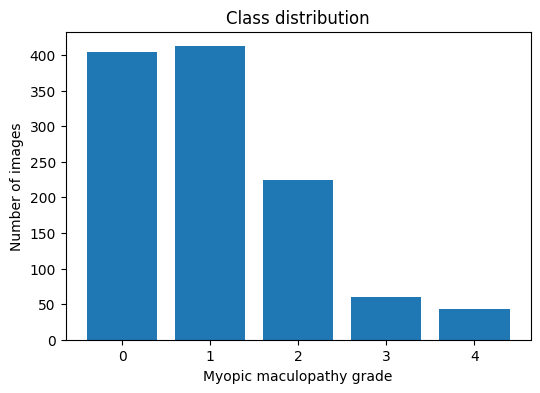

In [3]:
# Class distribution of dataset
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Myopic maculopathy grade")
plt.ylabel("Number of images")
plt.title("Class distribution")
plt.show()

## Data transformation

In [4]:
# Image preprocessing: Images are converted to grayscale resized and normalised
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])])

In [5]:
# Custom dataset to load images and corresponding labels
class MMACDataset(Dataset):
    def __init__(self, df, images_folder, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image name and label from dataframe
        image_name = self.df.loc[idx, "image"]
        label = int(self.df.loc[idx, "myopic_maculopathy_grade"])

        # Load image
        image_path = os.path.join(self.images_folder, image_name)
        image = Image.open(image_path).convert("L")

        # Apply preprocessing
        if self.transform is not None:
            image = self.transform(image)

        # Return image and label
        return {"image": image,
            "label": torch.tensor(label, dtype=torch.long) }

In [6]:
# dataset and dataloader
train_dataset = MMACDataset(train_df, train_images_folder, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


## Classification model
CNN model to classify myopic maculopathy grade. Dropout is included so the model can be run multiple times to measure uncertainty.

In [7]:
# simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5, dropout_p=0.3):
        super().__init__()

        # Convolutional feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) )

        # Classification layers with dropout
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(64, num_classes) )

    def forward(self, x):
        # Forward pass
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
model = SimpleCNN(num_classes=5, dropout_p=0.3)

## Training setup

In [9]:
# Set device, loss function and optimiser
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
# Train the model for one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Track loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        
        # Compute accuracy
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [11]:
# Train model for multiple epochs and store loss
num_epochs = 10
train_losses = []

#progress
for epoch in tqdm(range(num_epochs), desc="Training"):
    train_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

Training: 100%|██████████| 10/10 [07:55<00:00, 47.52s/it]


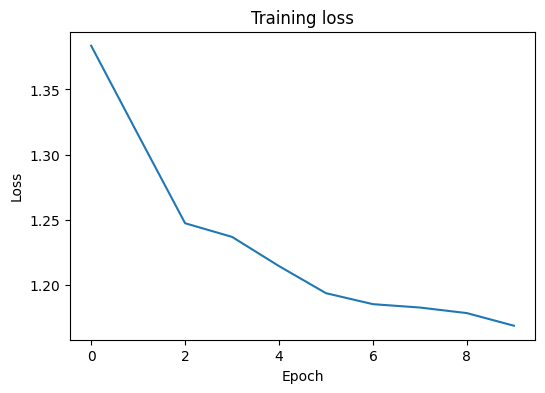

In [12]:
# Plot training loss over epochs
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

## Uncertainty estimation using dropout

Dropout randomly turns off parts of the network. Running the model multiple times gives different predictions, and their variation is used to measure uncertainty.

In [13]:
# Run the model multiple times with dropout to estimate uncertainty
def mc_dropout_inference(model, images, T=10):
    model.train()  # keep dropout active

    preds = []

    # Multiple forward passes
    for _ in range(T):
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds.append(probs)

    preds = torch.stack(preds)

    # Average prediction and variability
    mean_pred = preds.mean(dim=0)
    uncertainty = preds.var(dim=0)

    return mean_pred, uncertainty

In [14]:
# Take one batch and run uncertainty estimation
batch = next(iter(train_loader))

images = batch["image"].to(device)
labels = batch["label"].to(device)

# Get predictions and uncertainty
mean_pred, uncertainty = mc_dropout_inference(model, images, T=10)

# Predicted classes
preds = torch.argmax(mean_pred, dim=1)

# Move to CPU for analysis
preds = preds.cpu()
labels = labels.cpu()
uncertainty = uncertainty.cpu()

# Number of correct predictions in batch
num_correct = (preds == labels).sum().item()
print("Correct predictions:", num_correct)

Correct predictions: 7


## Uncertainty and prediction correctness

The uncertainty values are compared between correct and incorrect predictions.

In [16]:
# Compute uncertainty score per image and check if prediction is correct
uncertainty_score = uncertainty.mean(dim=1)
correct_predictions = (preds == labels)

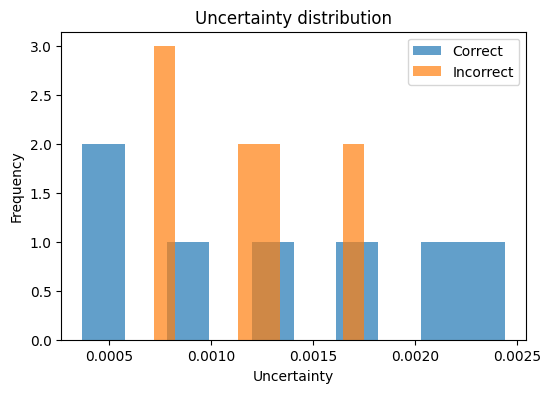

In [17]:
# Compare uncertainty for correct and incorrect predictions
correct_uncertainty = uncertainty_score[correct_predictions]
incorrect_uncertainty = uncertainty_score[~correct_predictions]

# Plot uncertainty distribution
plt.figure(figsize=(6, 4))

plt.hist(correct_uncertainty.detach().numpy(), bins=10, alpha=0.7, label="Correct")
plt.hist(incorrect_uncertainty.detach().numpy(), bins=10, alpha=0.7, label="Incorrect")

plt.xlabel("Uncertainty")
plt.ylabel("Frequency")
plt.title("Uncertainty distribution")
plt.legend()

plt.show()
